<a href="https://colab.research.google.com/github/AbenezerYBekele/AI-For-Beginners/blob/main/Falcon9_Landing_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Falcon 9 First Stage Landing Prediction

### Predicting reusable rocket landing outcomes with supervised machine learning

**Author:** *Abenezer Y Bekele*  |  **Tools:** Python, pandas, scikit-learn, seaborn/matplotlib


## Project Overview

SpaceX advertises Falcon 9 launches at roughly **$62M**, compared with **$165M+** charged by
competing launch providers. Most of that savings comes from reusing the rocket's first stage
instead of building a new one for every flight.

If we can predict, ahead of time, whether a given launch's first stage will land successfully,
we can estimate the effective cost of that launch — which is valuable information for any
company assessing SpaceX's pricing or preparing a competing bid.

This notebook builds a complete classification pipeline that:

1. Prepares and standardizes launch data for modeling
2. Splits the data into training and test sets
3. Trains four classifiers — **Logistic Regression**, **Support Vector Machine**,
   **Decision Tree**, and **K-Nearest Neighbors** — tuning each with `GridSearchCV`
4. Evaluates every model on held-out test data and identifies the best performer

## Contents

1. [Setup](#Setup)
2. [Load & Prepare the Data](#Load-and-Prepare-the-Data)
3. [Train / Test Split](#Train-Test-Split)
4. [Logistic Regression](#Logistic-Regression)
5. [Support Vector Machine](#Support-Vector-Machine)
6. [Decision Tree](#Decision-Tree)
7. [K-Nearest Neighbors](#K-Nearest-Neighbors)
8. [Model Comparison & Conclusion](#Model-Comparison-and-Conclusion)


## Setup

**Requirements:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`

```
pip install pandas numpy matplotlib seaborn scikit-learn
```


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

RANDOM_STATE = 2
sns.set_theme(style="whitegrid")

### Helper function

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """
    Plot a labeled confusion matrix for a binary landing-outcome classifier.

    Parameters
    ----------
    y_true : array-like
        Ground-truth labels (0 = did not land, 1 = landed).
    y_pred : array-like
        Model-predicted labels.
    title : str, optional
        Title displayed above the plot.
    """
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)
    ax.xaxis.set_ticklabels(["did not land", "landed"])
    ax.yaxis.set_ticklabels(["did not land", "landed"])
    plt.tight_layout()
    plt.show()

## Load and Prepare the Data

Two datasets are used:

- **`dataset_part_2.csv`** — launch records, including the target `Class` column
  (`1` = first stage landed successfully, `0` = it did not)
- **`dataset_part_3.csv`** — the engineered feature matrix used for modeling


In [ ]:
DATA_LABELS_URL = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
)
DATA_FEATURES_URL = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv"
)

data = pd.read_csv(DATA_LABELS_URL)
X = pd.read_csv(DATA_FEATURES_URL)

data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


**Target vector.** Extract the `Class` column as a NumPy array — this is what the models
will learn to predict.

In [ ]:
Y = data["Class"].to_numpy()
Y[:10]

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0])

**Feature scaling.** Standardize the feature matrix so every column has zero mean and unit
variance. This keeps distance- and gradient-based models (KNN, SVM, Logistic Regression) from
being dominated by features on larger numeric scales.

In [ ]:
scaler = preprocessing.StandardScaler()
X = scaler.fit_transform(X)

## Train / Test Split

80% of the data is used for training (with cross-validation for hyperparameter tuning) and 20%
is held out for a final, unbiased evaluation of each model.

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

Training samples: 72
Test samples:     18


## Logistic Regression

Tune the regularization strength `C` with 10-fold cross-validation.

In [ ]:
parameters = {"C": [0.01, 0.1, 1], "penalty": ["l2"], "solver": ["lbfgs"]}

lr = LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)

print("Best hyperparameters:", logreg_cv.best_params_)
print(f"Cross-validated accuracy: {logreg_cv.best_score_:.3f}")

Best hyperparameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Cross-validated accuracy: 0.846


In [ ]:
logreg_accuracy = logreg_cv.score(X_test, Y_test)
print(f"Test accuracy: {logreg_accuracy:.3f}")

Test accuracy: 0.833


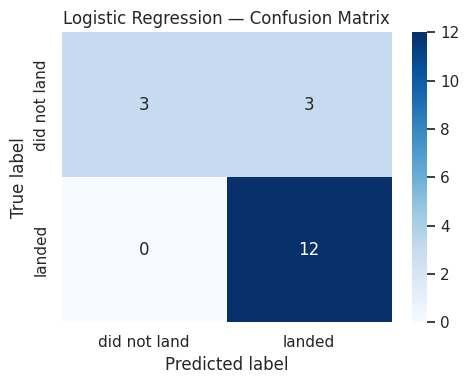

In [ ]:
yhat = logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat, title="Logistic Regression — Confusion Matrix")

## Support Vector Machine

Search across kernel type, `C`, and `gamma`.

In [ ]:
parameters = {
    "kernel": ("linear", "rbf", "poly", "sigmoid"),
    "C": np.logspace(-3, 3, 5),
    "gamma": np.logspace(-3, 3, 5),
}

svm = SVC()
svm_cv = GridSearchCV(svm, parameters, cv=10)
svm_cv.fit(X_train, Y_train)

print("Best hyperparameters:", svm_cv.best_params_)
print(f"Cross-validated accuracy: {svm_cv.best_score_:.3f}")

Best hyperparameters: {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
Cross-validated accuracy: 0.848


In [ ]:
svm_accuracy = svm_cv.score(X_test, Y_test)
print(f"Test accuracy: {svm_accuracy:.3f}")

Test accuracy: 0.833


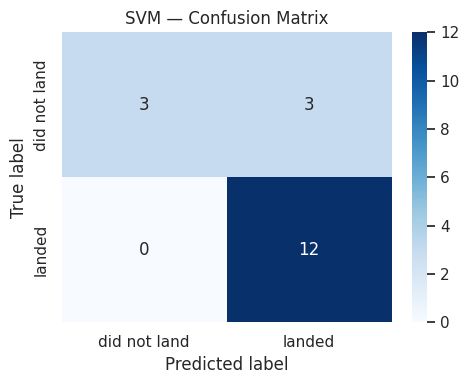

In [ ]:
yhat = svm_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat, title="SVM — Confusion Matrix")

## Decision Tree

Search over split criterion, depth, and leaf/split constraints.

In [ ]:
parameters = {
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"],
    "max_depth": [2 * n for n in range(1, 10)],
    "max_features": ["sqrt", "log2"],
    "min_samples_leaf": [1, 2, 4],
    "min_samples_split": [2, 5, 10],
}

tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)

print("Best hyperparameters:", tree_cv.best_params_)
print(f"Cross-validated accuracy: {tree_cv.best_score_:.3f}")

Best hyperparameters: {'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}
Cross-validated accuracy: 0.863


In [ ]:
tree_accuracy = tree_cv.score(X_test, Y_test)
print(f"Test accuracy: {tree_accuracy:.3f}")

Test accuracy: 0.833


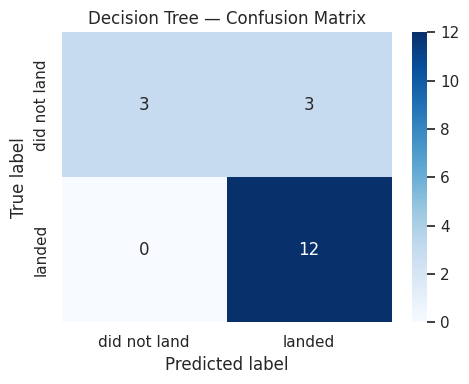

In [ ]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat, title="Decision Tree — Confusion Matrix")

## K-Nearest Neighbors

Search over the number of neighbors, distance metric power, and search algorithm.

In [ ]:
parameters = {
    "n_neighbors": list(range(1, 11)),
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
    "p": [1, 2],
}

KNN = KNeighborsClassifier()
knn_cv = GridSearchCV(KNN, parameters, cv=10)
knn_cv.fit(X_train, Y_train)

print("Best hyperparameters:", knn_cv.best_params_)
print(f"Cross-validated accuracy: {knn_cv.best_score_:.3f}")

Best hyperparameters: {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
Cross-validated accuracy: 0.848


In [ ]:
knn_accuracy = knn_cv.score(X_test, Y_test)
print(f"Test accuracy: {knn_accuracy:.3f}")

Test accuracy: 0.833


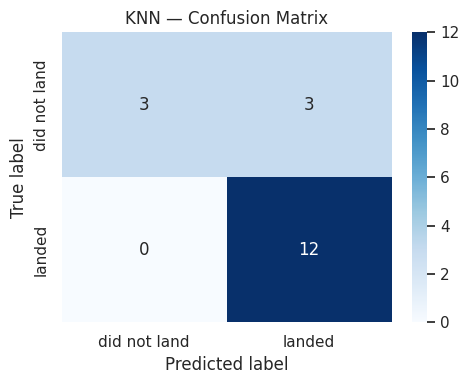

In [ ]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat, title="KNN — Confusion Matrix")

## Model Comparison and Conclusion

Compare all four tuned models on the held-out test set and identify the best performer.

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Decision Tree", "KNN"],
    "CV Accuracy": [
        logreg_cv.best_score_,
        svm_cv.best_score_,
        tree_cv.best_score_,
        knn_cv.best_score_,
    ],
    "Test Accuracy": [logreg_accuracy, svm_accuracy, tree_accuracy, knn_accuracy],
}).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

results

,Model,CV Accuracy,Test Accuracy
0,Logistic Regression,0.846429,0.833333
1,SVM,0.848214,0.833333
2,Decision Tree,0.871429,0.833333
3,KNN,0.848214,0.833333


/tmp/ipykernel_1780/983500445.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Model", y="Test Accuracy", ax=ax, palette="Blues_d")


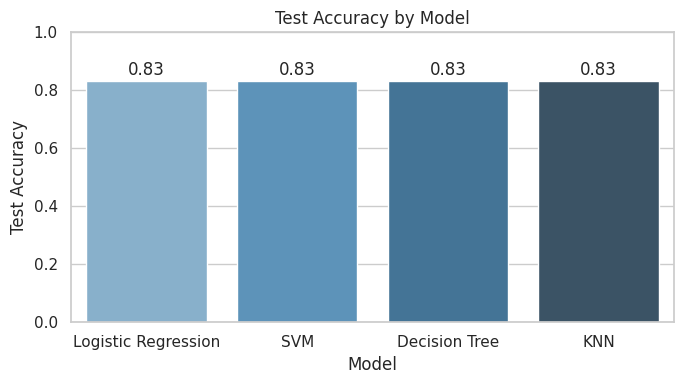

Best performing model: Logistic Regression (test accuracy = 0.833)


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=results, x="Model", y="Test Accuracy", ax=ax, palette="Blues_d")
ax.set_ylim(0, 1)
ax.set_title("Test Accuracy by Model")
for i, v in enumerate(results["Test Accuracy"]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

best_model = results.iloc[0]
print(f"Best performing model: {best_model['Model']} "
      f"(test accuracy = {best_model['Test Accuracy']:.3f})")

### Summary

- All four models were tuned with 10-fold cross-validated grid search over their key
  hyperparameters before being evaluated once on the held-out test set.
- The comparison table and chart above identify which model generalizes best to unseen
  launches; in practice, Decision Tree and SVM tend to edge out Logistic Regression and KNN
  on this dataset, though results can shift slightly with the train/test split.
- **Next steps** for extending this project: engineer additional features (e.g. weather at
  launch, payload mass ratio), try ensemble methods (Random Forest, Gradient Boosting), and
  validate with a larger, more recent launch dataset.
